# SMS Spam Detection - Naive Bayes
**Gray Interface '26 | Task 3 - Part 2**

Dataset: SMS Spam Collection

## Importing the Dependencies

In [ ]:
!pip install kagglehub nltk --quiet


In [ ]:
import kagglehub
import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Loading the Dataset

In [ ]:
# Downloading the SMS Spam Collection dataset from Kaggle
path = kagglehub.dataset_download("abhishek14398/sms-spam-collection")
print(os.listdir(path))


100%|██████████| 415k/415k [00:00<00:00, 91.8MB/s]

Extracting files...
['SMSSpamCollection.csv', 'SpamCollectionSMS.txt']


In [ ]:
# File is tab-separated with no header
# Kaggle package may use either of these names
candidates = ['SpamCollectionSMS.txt', 'SMSSpamCollection.csv', 'SMSSpamCollection']
data_file = next(f for f in candidates if os.path.exists(os.path.join(path, f)))

sms_data = pd.read_csv(
    os.path.join(path, data_file),
    sep='\t', header=None, names=['label', 'message']
)
print("Loaded:", data_file)
print("Dataset Shape:", sms_data.shape)
sms_data.head()


Loaded: SpamCollectionSMS.txt
Dataset Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Basic Dataset Information

In [ ]:
# Checking for missing values
sms_data.isnull().sum()


,0
label,0
message,0


In [ ]:
# Class distribution: ham = not spam, spam = spam
print(sms_data['label'].value_counts())
print()
print(sms_data['label'].value_counts(normalize=True) * 100)


label
ham     4825
spam     747
Name: count, dtype: int64

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


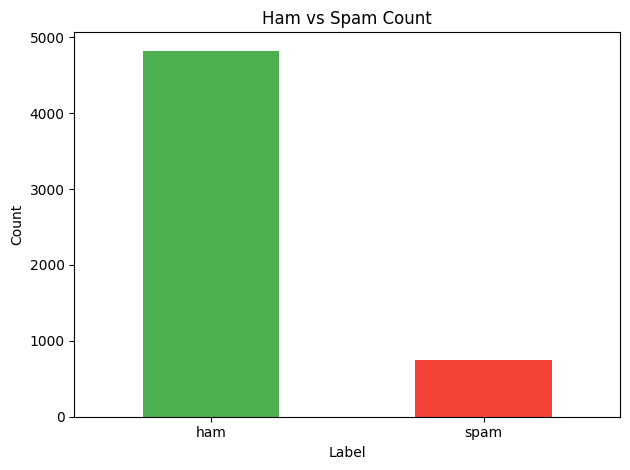

In [ ]:
# Plotting class distribution
sms_data['label'].value_counts().plot(kind='bar', color=['#4CAF50', '#F44336'])
plt.title('Ham vs Spam Count')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Observations so far
- No missing values
- Dataset is imbalanced: much more ham than spam
- Because of this, Accuracy alone is not enough — Precision, Recall, F1 and ROC-AUC matter more


## Text Preprocessing

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenize and remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

sms_data['cleaned'] = sms_data['message'].apply(clean_text)

# Checking original vs cleaned text
print('Original:', sms_data['message'][0])
print('Cleaned :', sms_data['cleaned'][0])


Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned : go jurong point crazy available bugis n great world la e buffet cine got amore wat


## Encoding the Labels

In [ ]:
# ham = 0, spam = 1
sms_data['label_enc'] = sms_data['label'].map({'ham': 0, 'spam': 1})
sms_data['label_enc'].value_counts()


,count
label_enc,
0,4825
1,747


## Train Test Split

In [ ]:
X = sms_data['cleaned']
Y = sms_data['label_enc']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2, stratify=Y
)
print(X.shape, X_train.shape, X_test.shape)


(5572,) (4457,) (1115,)


## Helper Function for Evaluation

In [ ]:
def evaluate_model(model, X_test_vec, Y_test, name="Model"):
    pred = model.predict(X_test_vec)
    # predict_proba for ROC-AUC (probability of spam class)
    prob = model.predict_proba(X_test_vec)[:, 1]

    acc = accuracy_score(Y_test, pred)
    prec = precision_score(Y_test, pred)
    rec = recall_score(Y_test, pred)
    f1 = f1_score(Y_test, pred)
    auc = roc_auc_score(Y_test, prob)

    print(f"===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(Y_test, pred))
    print()
    return {'name': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': auc}


## CountVectorizer + Unigrams

In [ ]:
# CountVectorizer converts text into word counts
cv = CountVectorizer(ngram_range=(1, 1))
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

print("Vocabulary size:", len(cv.get_feature_names_out()))

all_results = []
alphas = [0.1, 0.5, 1.0, 2.0, 5.0]

for alpha in alphas:
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_cv, Y_train)
    res = evaluate_model(model, X_test_cv, Y_test, name=f"Count + Uni | alpha={alpha}")
    all_results.append(res)


Vocabulary size: 8429
===== Count + Uni | alpha=0.1 =====
Accuracy : 0.9821
Precision: 0.9510
Recall   : 0.9128
F1-Score : 0.9315
ROC-AUC  : 0.9741
Confusion Matrix:
[[959   7]
 [ 13 136]]

===== Count + Uni | alpha=0.5 =====
Accuracy : 0.9857
Precision: 0.9650
Recall   : 0.9262
F1-Score : 0.9452
ROC-AUC  : 0.9750
Confusion Matrix:
[[961   5]
 [ 11 138]]

===== Count + Uni | alpha=1.0 =====
Accuracy : 0.9857
Precision: 0.9716
Recall   : 0.9195
F1-Score : 0.9448
ROC-AUC  : 0.9740
Confusion Matrix:
[[962   4]
 [ 12 137]]

===== Count + Uni | alpha=2.0 =====
Accuracy : 0.9803
Precision: 0.9847
Recall   : 0.8658
F1-Score : 0.9214
ROC-AUC  : 0.9707
Confusion Matrix:
[[964   2]
 [ 20 129]]

===== Count + Uni | alpha=5.0 =====
Accuracy : 0.9758
Precision: 1.0000
Recall   : 0.8188
F1-Score : 0.9004
ROC-AUC  : 0.9601
Confusion Matrix:
[[966   0]
 [ 27 122]]



## CountVectorizer + Bigrams

In [ ]:
# Bigrams also consider pairs of consecutive words
cv_bi = CountVectorizer(ngram_range=(1, 2))
X_train_cvbi = cv_bi.fit_transform(X_train)
X_test_cvbi = cv_bi.transform(X_test)

print("Vocabulary size:", len(cv_bi.get_feature_names_out()))

for alpha in alphas:
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_cvbi, Y_train)
    res = evaluate_model(model, X_test_cvbi, Y_test, name=f"Count + Bi | alpha={alpha}")
    all_results.append(res)


Vocabulary size: 35488
===== Count + Bi | alpha=0.1 =====
Accuracy : 0.9848
Precision: 0.9521
Recall   : 0.9329
F1-Score : 0.9424
ROC-AUC  : 0.9741
Confusion Matrix:
[[959   7]
 [ 10 139]]

===== Count + Bi | alpha=0.5 =====
Accuracy : 0.9848
Precision: 0.9714
Recall   : 0.9128
F1-Score : 0.9412
ROC-AUC  : 0.9730
Confusion Matrix:
[[962   4]
 [ 13 136]]

===== Count + Bi | alpha=1.0 =====
Accuracy : 0.9830
Precision: 0.9779
Recall   : 0.8926
F1-Score : 0.9333
ROC-AUC  : 0.9710
Confusion Matrix:
[[963   3]
 [ 16 133]]

===== Count + Bi | alpha=2.0 =====
Accuracy : 0.9812
Precision: 1.0000
Recall   : 0.8591
F1-Score : 0.9242
ROC-AUC  : 0.9654
Confusion Matrix:
[[966   0]
 [ 21 128]]

===== Count + Bi | alpha=5.0 =====
Accuracy : 0.9776
Precision: 1.0000
Recall   : 0.8322
F1-Score : 0.9084
ROC-AUC  : 0.9545
Confusion Matrix:
[[966   0]
 [ 25 124]]



## TF-IDF Vectorizer + Unigrams

In [ ]:
# TF-IDF gives higher weight to words that are unique to a message
# and lower weight to common words that appear everywhere
tfidf = TfidfVectorizer(ngram_range=(1, 1))
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf = tfidf.transform(X_test)

print("Vocabulary size:", len(tfidf.get_feature_names_out()))

for alpha in alphas:
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_tf, Y_train)
    res = evaluate_model(model, X_test_tf, Y_test, name=f"TFIDF + Uni | alpha={alpha}")
    all_results.append(res)


Vocabulary size: 8429
===== TFIDF + Uni | alpha=0.1 =====
Accuracy : 0.9839
Precision: 0.9852
Recall   : 0.8926
F1-Score : 0.9366
ROC-AUC  : 0.9867
Confusion Matrix:
[[964   2]
 [ 16 133]]

===== TFIDF + Uni | alpha=0.5 =====
Accuracy : 0.9749
Precision: 0.9919
Recall   : 0.8188
F1-Score : 0.8971
ROC-AUC  : 0.9837
Confusion Matrix:
[[965   1]
 [ 27 122]]

===== TFIDF + Uni | alpha=1.0 =====
Accuracy : 0.9614
Precision: 1.0000
Recall   : 0.7114
F1-Score : 0.8314
ROC-AUC  : 0.9798
Confusion Matrix:
[[966   0]
 [ 43 106]]

===== TFIDF + Uni | alpha=2.0 =====
Accuracy : 0.9372
Precision: 1.0000
Recall   : 0.5302
F1-Score : 0.6930
ROC-AUC  : 0.9744
Confusion Matrix:
[[966   0]
 [ 70  79]]

===== TFIDF + Uni | alpha=5.0 =====
Accuracy : 0.8897
Precision: 1.0000
Recall   : 0.1745
F1-Score : 0.2971
ROC-AUC  : 0.9647
Confusion Matrix:
[[966   0]
 [123  26]]



## TF-IDF Vectorizer + Bigrams

In [ ]:
tfidf_bi = TfidfVectorizer(ngram_range=(1, 2))
X_train_tfbi = tfidf_bi.fit_transform(X_train)
X_test_tfbi = tfidf_bi.transform(X_test)

print("Vocabulary size:", len(tfidf_bi.get_feature_names_out()))

for alpha in alphas:
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_tfbi, Y_train)
    res = evaluate_model(model, X_test_tfbi, Y_test, name=f"TFIDF + Bi | alpha={alpha}")
    all_results.append(res)


Vocabulary size: 35488
===== TFIDF + Bi | alpha=0.1 =====
Accuracy : 0.9830
Precision: 0.9851
Recall   : 0.8859
F1-Score : 0.9329
ROC-AUC  : 0.9835
Confusion Matrix:
[[964   2]
 [ 17 132]]

===== TFIDF + Bi | alpha=0.5 =====
Accuracy : 0.9695
Precision: 1.0000
Recall   : 0.7718
F1-Score : 0.8712
ROC-AUC  : 0.9772
Confusion Matrix:
[[966   0]
 [ 34 115]]

===== TFIDF + Bi | alpha=1.0 =====
Accuracy : 0.9543
Precision: 1.0000
Recall   : 0.6577
F1-Score : 0.7935
ROC-AUC  : 0.9731
Confusion Matrix:
[[966   0]
 [ 51  98]]

===== TFIDF + Bi | alpha=2.0 =====
Accuracy : 0.9193
Precision: 1.0000
Recall   : 0.3960
F1-Score : 0.5673
ROC-AUC  : 0.9679
Confusion Matrix:
[[966   0]
 [ 90  59]]

===== TFIDF + Bi | alpha=5.0 =====
Accuracy : 0.8709
Precision: 1.0000
Recall   : 0.0336
F1-Score : 0.0649
ROC-AUC  : 0.9610
Confusion Matrix:
[[966   0]
 [144   5]]



## Comparing All Experiments

In [ ]:
results_df = pd.DataFrame(all_results).sort_values('f1', ascending=False)
results_df


,name,accuracy,precision,recall,f1,roc_auc
1,Count + Uni | alpha=0.5,0.985650,0.965035,0.926174,0.945205,0.975009
2,Count + Uni | alpha=1.0,0.985650,0.971631,0.919463,0.944828,0.974016
5,Count + Bi | alpha=0.1,0.984753,0.952055,0.932886,0.942373,0.974106
6,Count + Bi | alpha=0.5,0.984753,0.971429,0.912752,0.941176,0.973015
10,TFIDF + Uni | alpha=0.1,0.983857,0.985185,0.892617,0.936620,0.986661
7,Count + Bi | alpha=1.0,0.982960,0.977941,0.892617,0.933333,0.970966
15,TFIDF + Bi | alpha=0.1,0.982960,0.985075,0.885906,0.932862,0.983534
0,Count + Uni | alpha=0.1,0.982063,0.951049,0.912752,0.931507,0.974113
8,Count + Bi | alpha=2.0,0.981166,1.000000,0.859060,0.924188,0.965352
3,Count + Uni | alpha=2.0,0.980269,0.984733,0.865772,0.921429,0.970723


## Training the Best Model

In [ ]:
# Pick best by F1 from the comparison table
best_name = results_df.iloc[0]['name']
print("Best pipeline:", best_name)

# Retrain a strong common setup: TF-IDF Unigrams + best alpha from that group
# (You can change this based on the table above)
best_alpha = 0.1
best_vectorizer = TfidfVectorizer(ngram_range=(1, 1))
X_train_best = best_vectorizer.fit_transform(X_train)
X_test_best = best_vectorizer.transform(X_test)

best_model = MultinomialNB(alpha=best_alpha)
best_model.fit(X_train_best, Y_train)

train_pred = best_model.predict(X_train_best)
test_pred = best_model.predict(X_test_best)

print("Accuracy on training data:", accuracy_score(Y_train, train_pred))
print("Accuracy on test data:", accuracy_score(Y_test, test_pred))
print()
print(classification_report(Y_test, test_pred, target_names=['Ham', 'Spam']))
print("Confusion Matrix:")
print(confusion_matrix(Y_test, test_pred))
print("ROC AUC:", roc_auc_score(Y_test, best_model.predict_proba(X_test_best)[:, 1]))


Best pipeline: Count + Uni | alpha=0.5
Accuracy on training data: 0.9982050706753421
Accuracy on test data: 0.9838565022421525

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Confusion Matrix:
[[964   2]
 [ 16 133]]
ROC AUC: 0.9866605527533453


## Key Findings

| # | Finding |
|---|---------|
| 1 | Dataset is imbalanced (more ham), so F1 and ROC-AUC are more useful than Accuracy alone |
| 2 | Text cleaning (lowercase, punctuation removal, stopwords) reduces noise |
| 3 | CountVectorizer and TF-IDF both work; TF-IDF often handles common words better |
| 4 | Unigrams are usually strong; bigrams add phrase context but make the vocabulary larger |
| 5 | Smaller alpha (less smoothing) often improves spam detection on this dataset |
| 6 | Best pipeline should balance Precision and Recall — missing spam vs marking ham as spam |
